# Backends and Algorithms

Quantum Launcher provides convenient wrappers for the most popular quantum computing backends, as well as a set of common quantum algorithms.

In [70]:
%load_ext autoreload
%autoreload 2

from qiskit_ibm_runtime.fake_provider import FakeSydneyV2, FakeAlmadenV2, FakeSherbrooke
from quantum_launcher.routines.qiskit_routines import QAOA, QiskitBackend, IBMBackend,AerBackend, FALQON
from quantum_launcher.routines.dwave_routines import SimulatedAnnealingBackend,DwaveSolver
from quantum_launcher.routines.orca_routines import OrcaBackend, BBS
from quantum_launcher.launcher import QuantumLauncher
from quantum_launcher.problems import EC,MaxCut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Qiskit

### QAOA

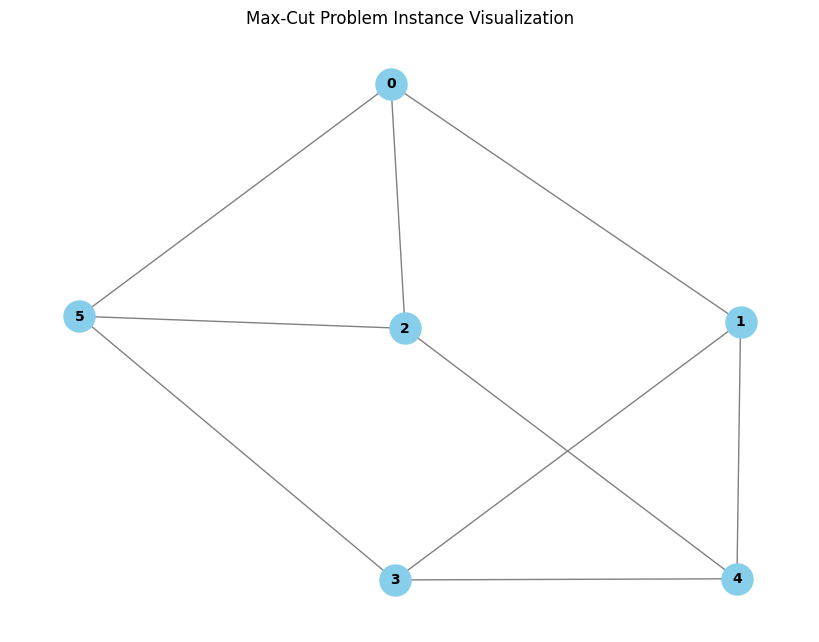

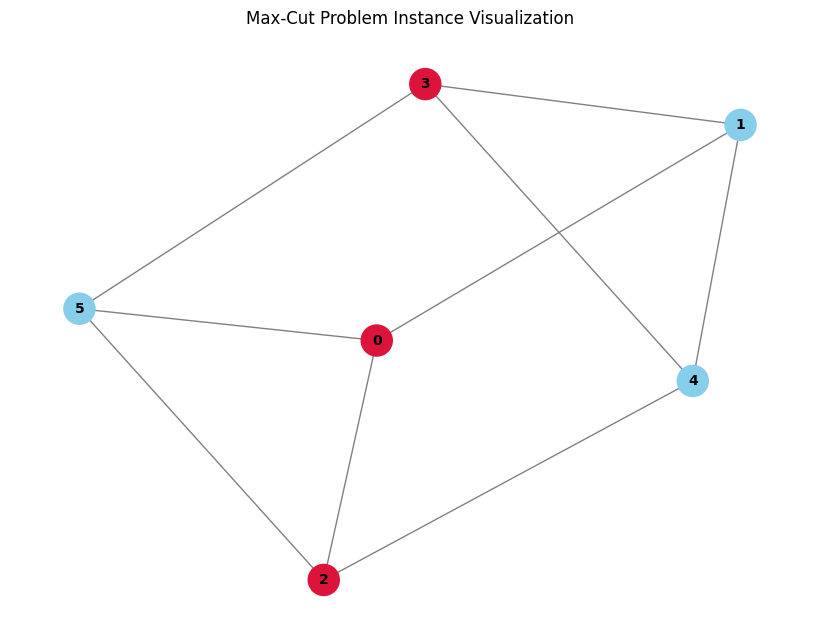

Result(bitstring=001101, energy=3.35546875)

In [77]:
pr = MaxCut.from_preset('default')
pr.visualize()

alg = QAOA()
backend = IBMBackend('backendv1v2',backendv1v2=FakeSherbrooke(),auto_transpile_level=0)

launcher = QuantumLauncher(pr, alg, backend)
result = launcher.run()
pr.visualize(result.best_bitstring[::-1])
result

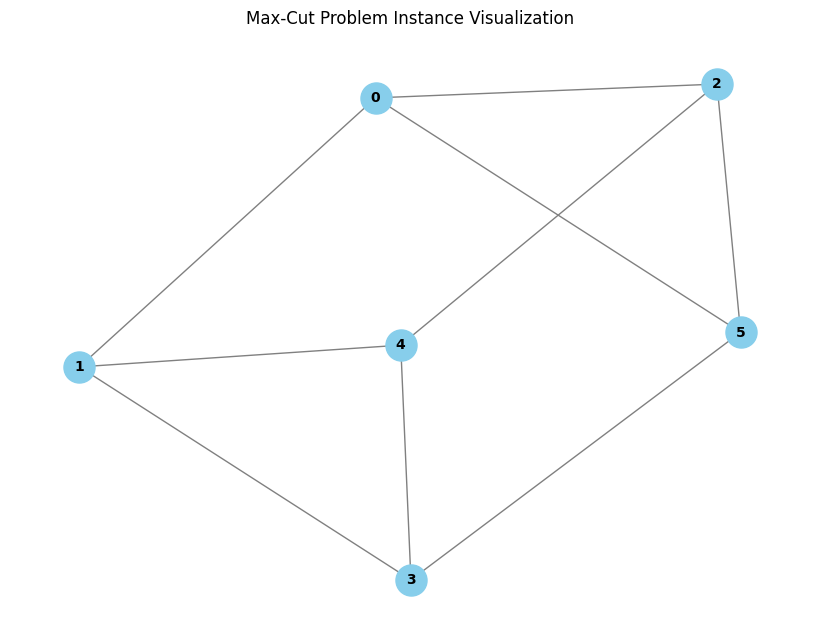

0 4.49169921875
1 4.45556640625
2 4.382568359375
3 4.264892578125
4 4.08056640625
5 3.9599609375
6 3.870849609375
7 3.73828125
8 3.708984375
9 3.6474609375
10 3.61474609375
11 3.577392578125
12 3.583984375
13 3.53369140625
14 3.53857421875


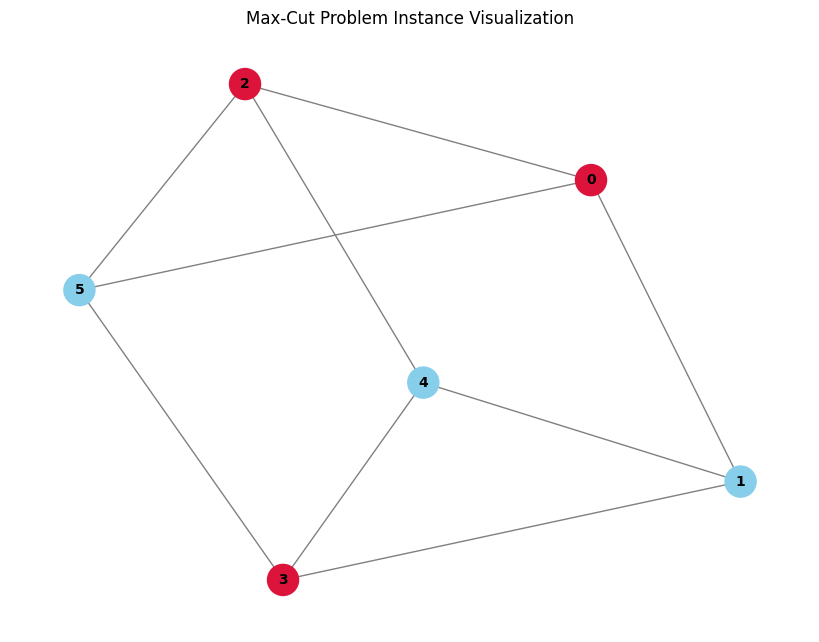

Result(bitstring=001101, energy=3.53369140625)

In [78]:
pr = MaxCut.from_preset('default')
pr.visualize()

alg = FALQON(max_reps=15)
backend = AerBackend('backendv1v2',backendv1v2=FakeSherbrooke(),auto_transpile_level=0)

launcher = QuantumLauncher(pr, alg, backend)
result = launcher.run()
pr.visualize(result.best_bitstring[::-1])
result

## D-Wave

### D-Wave backend and solver

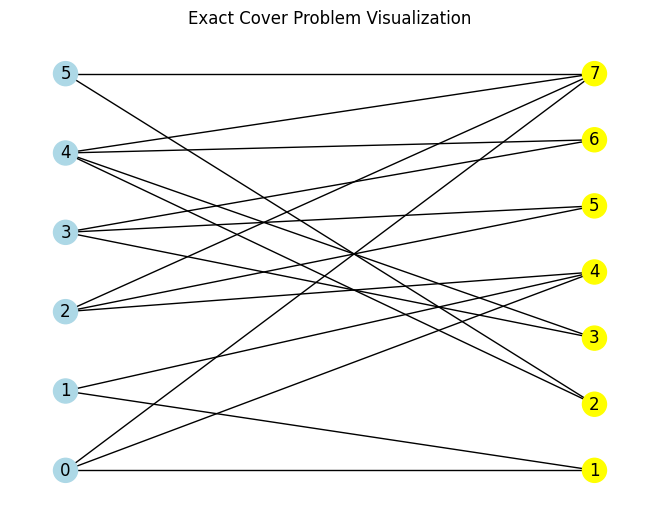

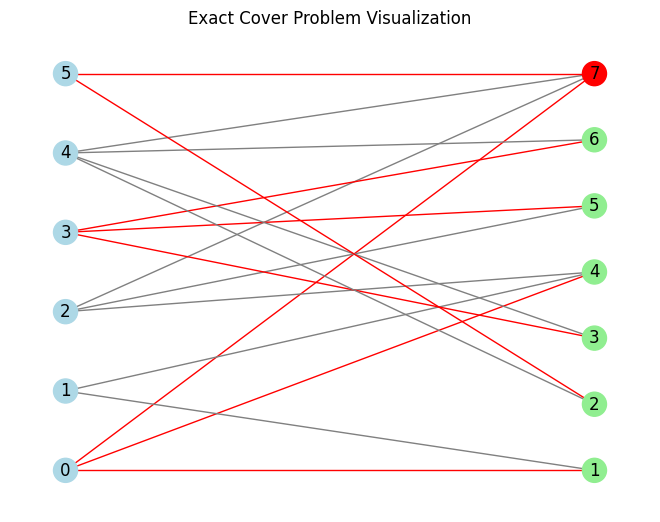

Result(bitstring=100101, energy=-9.5)

In [ ]:
pr = EC.from_preset("toy")
pr.visualize()

alg = DwaveSolver(1)
backend = SimulatedAnnealingBackend('local')
launcher = QuantumLauncher(pr, alg, backend)
result = launcher.run()
pr.visualize(result.best_bitstring)
result

## 

## Orca

### Orca backend and solver

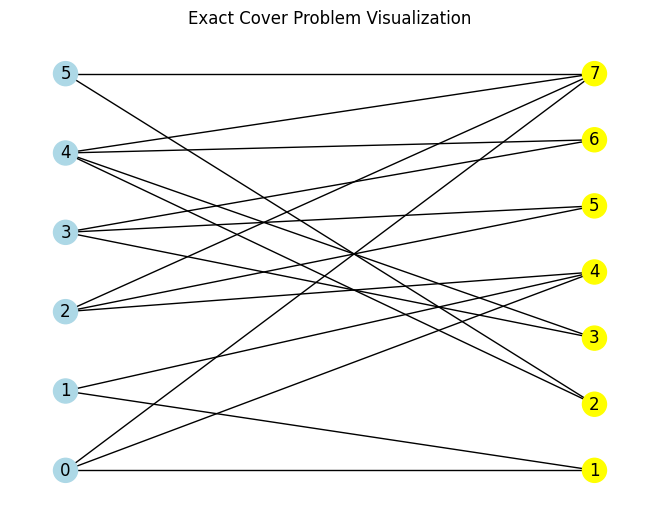

Training loop 1: loss is 0.67
Training loop 50: loss is -1.25
Training loop 100: loss is -1.35


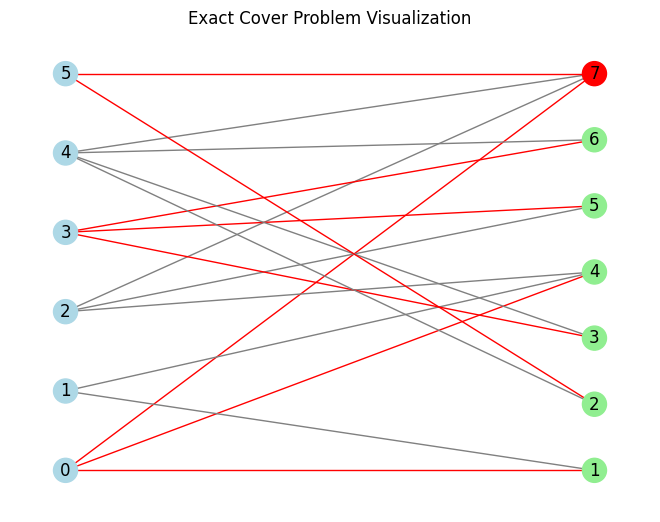

Result(bitstring=100101, energy=-1.5)

In [ ]:
pr = EC.from_preset("toy")
pr.visualize()

alg = BBS()
backend = OrcaBackend('local')
launcher = QuantumLauncher(pr, alg, backend)
result = launcher.run()

pr.visualize(result.best_bitstring)
result